In [5]:
import os
import pandas as pd
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import spectrogram
from scipy.io import wavfile
from pathlib import Path

In [3]:
metadata_file = r"C:\Users\ASUS\MMDP\RadioStream-30_Public_AM_FM\metadata.csv"
df = pd.read_csv(metadata_file)
df.head()

,Station Name,URL,Duration,Filepath,Timestamp
0,BBC World Service,http://stream.live.vc.bbcmedia.co.uk/bbc_world...,62,RadioStream-30_Public_AM_FM\BBC World Service_...,2025-03-09_22-38-27
1,NPR News,https://npr-ice.streamguys1.com/live.mp3,87,RadioStream-30_Public_AM_FM\NPR News_2025-03-0...,2025-03-09_22-39-52


In [10]:
df.shape

(2, 5)

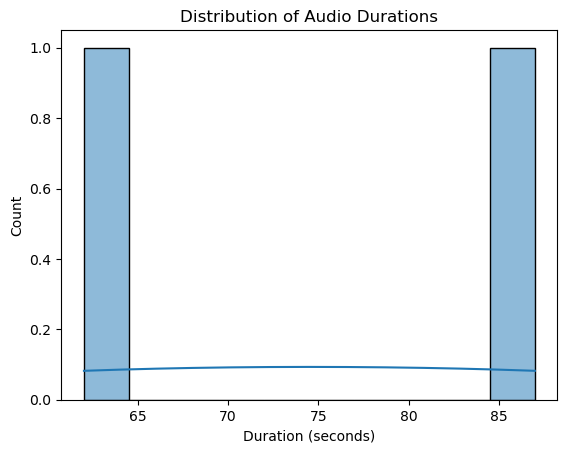

In [4]:
# Visualizing duration distribution
sns.histplot(df['Duration'], bins=10, kde=True)
plt.xlabel("Duration (seconds)")
plt.ylabel("Count")
plt.title("Distribution of Audio Durations")
plt.show()

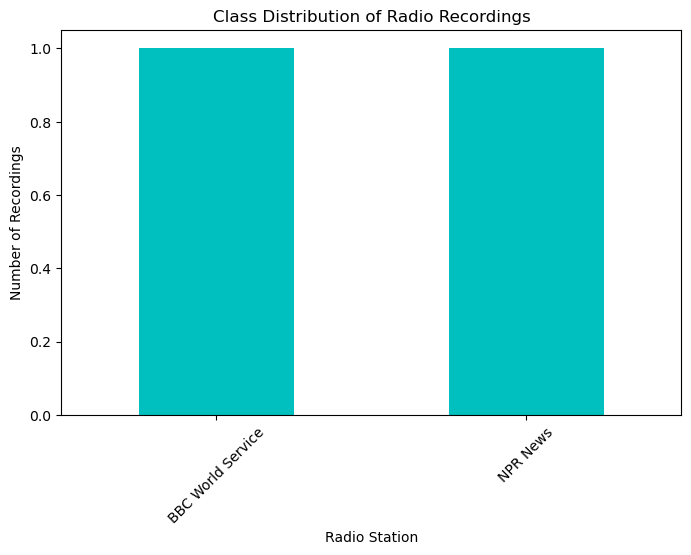

In [6]:
# Visualization 2: Class Distribution (Number of recordings per station)
plt.figure(figsize=(8, 5))
df["Station Name"].value_counts().plot(kind="bar", color="c")
plt.xlabel("Radio Station")
plt.ylabel("Number of Recordings")
plt.title("Class Distribution of Radio Recordings")
plt.xticks(rotation=45)
plt.show()

In [11]:
sample_audio = r"C:\Users\ASUS\MMDP\RadioStream-30_Public_AM_FM\BBC World Service_2025-03-09_22-37-34.wav" 
y, sr = librosa.load(sample_audio, sr=None)

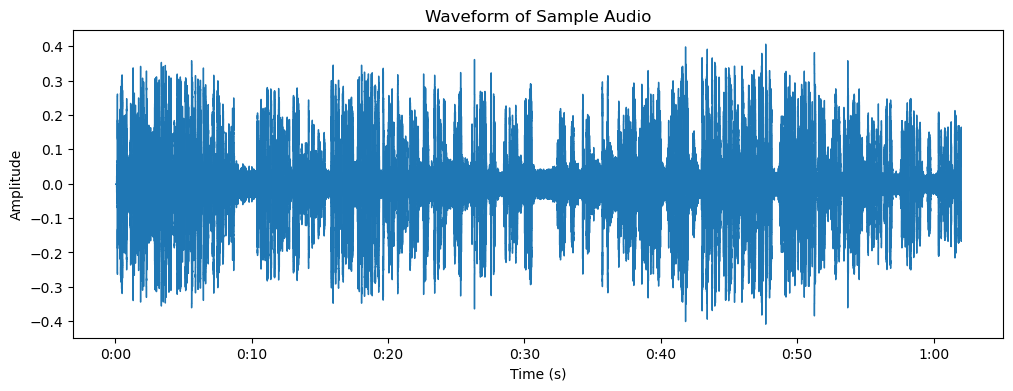

In [12]:
# Visualization 3: Waveform
plt.figure(figsize=(12, 4))
librosa.display.waveshow(y, sr=sr)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Waveform of Sample Audio")
plt.show()

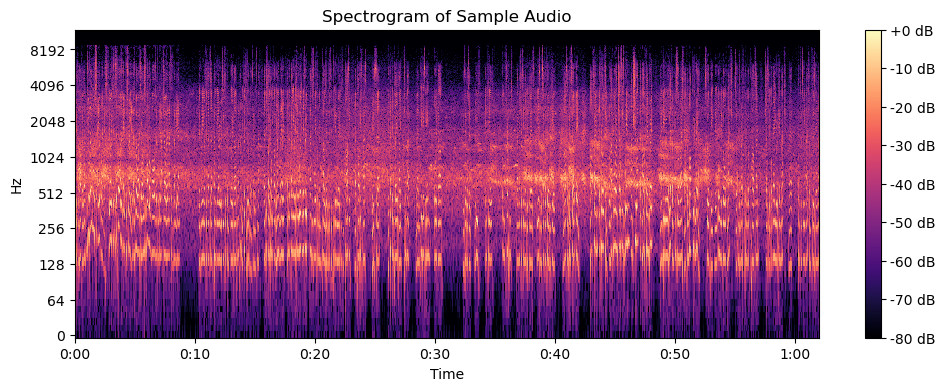

In [13]:
# Visualization 4: Spectrogram
plt.figure(figsize=(12, 4))
S = librosa.stft(y)
S_db = librosa.amplitude_to_db(np.abs(S), ref=np.max)
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='log')
plt.colorbar(format="%+2.0f dB")
plt.title("Spectrogram of Sample Audio")
plt.show()

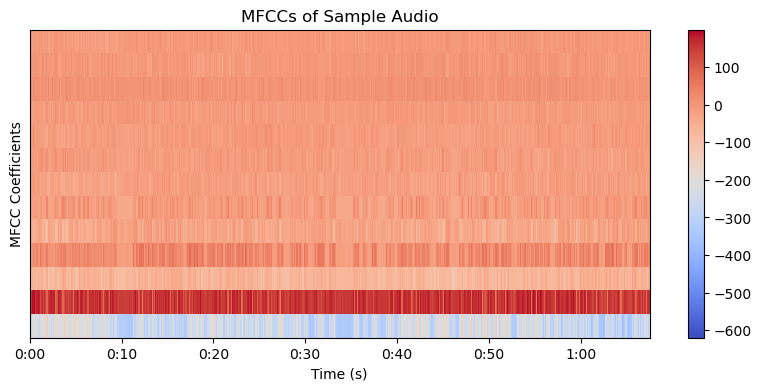

In [14]:
# Visualization 5: Mel-Frequency Cepstral Coefficients (MFCCs)
mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
plt.figure(figsize=(10, 4))
librosa.display.specshow(mfccs, x_axis="time")
plt.colorbar()
plt.title("MFCCs of Sample Audio")
plt.xlabel("Time (s)")
plt.ylabel("MFCC Coefficients")
plt.show()

In [15]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [16]:
def extract_mfcc(file_path, max_length=50):
    y, sr = librosa.load(file_path, sr=22050)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mfcc = np.mean(mfcc, axis=1)  # Take mean across time dimension
    return mfcc

In [17]:
def load_data(audio_dir):
    X, y = [], []
    labels = []
    for file in os.listdir(audio_dir):
        if file.endswith(".wav"):
            label = file.split("_")[0]  # Extract label from filename
            labels.append(label)
            mfcc_features = extract_mfcc(os.path.join(audio_dir, file))
            X.append(mfcc_features)
            y.append(label)
    
    return np.array(X), np.array(y), labels

In [18]:
audio_dir = r"C:\Users\ASUS\MMDP\RadioStream-30_Public_AM_FM"
X, y, labels = load_data(audio_dir)

In [19]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [20]:
X_train, X_val, y_train, y_val = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

In [22]:
y_encoded

array([0, 1], dtype=int64)

In [21]:
def create_model(input_shape, num_classes):
    model = keras.Sequential([
        layers.Dense(128, activation='relu', input_shape=(input_shape,)),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


In [23]:
num_classes = len(np.unique(y_encoded))
model = create_model(X_train.shape[1], num_classes)

c:\Users\ASUS\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10, batch_size=8)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 46.5670
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 791ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 50.3867
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 879ms/step - accuracy: 1.0000 - loss: 1.6689e-06 - val_accuracy: 0.0000e+00 - val_loss: 53.9213
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 57.1139
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 862ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 60.0026
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 908ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 62.6200
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 881ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 64.9120
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 754ms/step - accuracy:

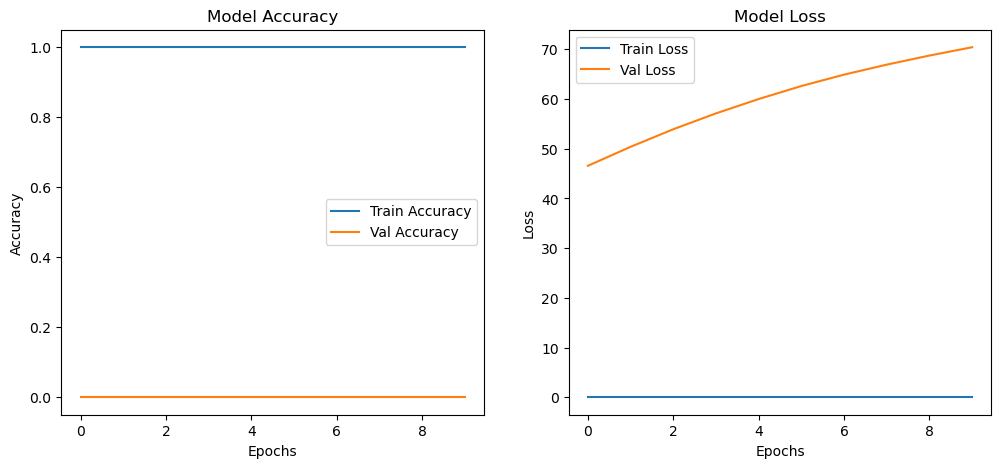

In [28]:
# Plot accuracy and loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()
